# Eksekusi Cuckoo Search - K-Means Clustering

Notebook ini didedikasikan secara khusus untuk **Data Preprocessing** dan **Eksekusi**. 
Seluruh tumpukan logika rumit (*back-end algoritmik*) seperti matematika Cuckoo Search, K-Means, dan perintah plot grafik visual 3D telah diekstraksi dengan sangat rapi ke file modular terpisah: `csa_core.py`.

In [1]:
# Install semua dependency
!pip install pandas numpy scikit-learn ipython matplotlib openpyxl

In [13]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from IPython.display import display

import sys
import os
sys.path.append(os.path.abspath('../src'))

# =============== IMPORT MODULE INTI ================
from csa_core import *

# Kunci reproduktibilitas random state
np.random.seed(42)

## 1. Data Preprocessing dan Pemilihan Dimensi Fitur

In [11]:
df_raw = pd.read_excel('../data/Data Set UMKM.xlsx', header=1)

kolom_dibutuhkan = ['Nama Usaha', 'Sektor Usaha', 'Omset per-Tahun', 'Usia', 'Laki-laki', 'Perempuan']
df = df_raw[kolom_dibutuhkan].copy()

# Membersihkan Value Kosong
df[['Usia', 'Laki-laki', 'Perempuan']] = df[['Usia', 'Laki-laki', 'Perempuan']].replace('-', 0).fillna(0)
df['Usia'] = pd.to_numeric(df['Usia'], errors='coerce').fillna(0)
df['Laki-laki'] = pd.to_numeric(df['Laki-laki'], errors='coerce').fillna(0)
df['Perempuan'] = pd.to_numeric(df['Perempuan'], errors='coerce').fillna(0)

# Persiapan Ekstraksi Dimensi Data
df['Total Pekerja Numeric'] = df['Laki-laki'] + df['Perempuan']
df['Usia Numeric'] = df['Usia']

df = df[df['Omset per-Tahun'] != '-'].dropna()
df = df.reset_index(drop=True)

def extract_omset(val):
    if 'Kurang dari 10 juta' in val:
        return 5.0
    elif '10 juta s/d 25 juta' in val:
        return 17.5
    elif '25 juta s/d 40 juta' in val:
        return 32.5
    elif '40 juta s/d 55 juta' in val:
        return 47.5
    elif '55 juta s/d 70 juta' in val:
        return 62.5
    elif '70 juta s/d 85 juta' in val:
        return 77.5
    elif '85 juta s/d 100 juta' in val:
        return 92.5
    elif '100 juta s/d 120 juta' in val:
        return 110.0
    elif '120 juta s/d 150 juta' in val:
        return 135.0
    elif 'Lebih dari 150 juta' in val:
        return 150.0
    else:
        return 5.0

df['Omset Numeric'] = df['Omset per-Tahun'].apply(extract_omset)

le = LabelEncoder()
df['Sektor Numeric'] = le.fit_transform(df['Sektor Usaha'].astype(str))

# =======================================================
# TENTUKAN KERANGKA DIMENSI DI SINI: 
# (Aktifkan baris yang tidak diawali tanda Pagar #)
# =======================================================

#(Pilihan A) KEMBALI KE 2 DIMENSI (X, Y)
# fitur_yang_dipakai = ['Sektor Numeric', 'Omset Numeric']

#(Pilihan B) MENGGUNAKAN 3 DIMENSI (X, Y, Z)
# fitur_yang_dipakai = ['Sektor Numeric', 'Omset Numeric', 'Usia Numeric']

#(Pilihan C) MENGGUNAKAN 4 DIMENSI (X, Y, Z, +Warna)
fitur_yang_dipakai = ['Sektor Numeric', 'Omset Numeric', 'Usia Numeric', 'Total Pekerja Numeric']

X_raw = df[fitur_yang_dipakai].values

# STANDARISASI
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)
print(f"Data yang digunakan diproses dalam skala {len(fitur_yang_dipakai)} Dimensi!")
display(df[['Nama Usaha'] + fitur_yang_dipakai].head(5))

Data yang digunakan diproses dalam skala 4 Dimensi!


,Nama Usaha,Sektor Numeric,Omset Numeric,Usia Numeric,Total Pekerja Numeric
0,NASYWA SNACK,20,5.0,41,0
1,WARUNG ABINAYA,20,5.0,41,0
2,TUNGKU MA ENDANG,20,5.0,53,2
3,WARUNG BU WIWIK,12,5.0,61,4
4,WARUNG PNUNG,20,5.0,64,0


## 2. Penentuan Optimal Kluster otomatis (Elbow L-Bow Method)

Mengkalkulasi K-Optimal...


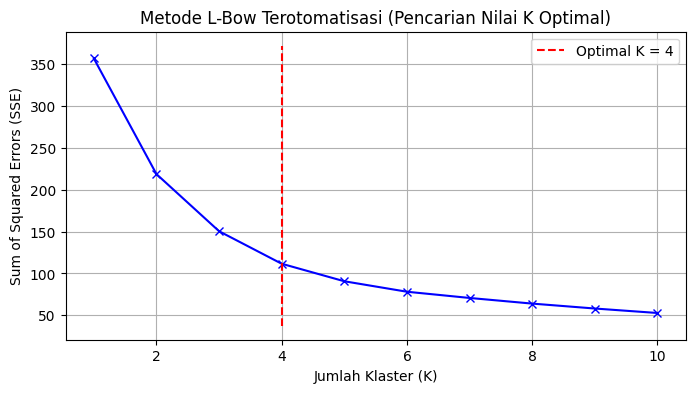

Nilai Evaluasi Algoritma Elbow menyarankan Kluster terbaik adalah K : 4


In [4]:
# Memanggil fungsi ajaib dari csa_core.py
print("Mengkalkulasi K-Optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=10)
print(f"Nilai Evaluasi Algoritma Elbow menyarankan Kluster terbaik adalah K : {optimal_k}")

## 3. Eksekusi Program Model (Cuckoo Search → K-Means)

In [5]:
print(f"Mengeksekusi Iterasi Cuckoo Search Algoritma Pada Data {len(fitur_yang_dipakai)} Dimensi...")
best_cuckoo_centroids_scaled, iterations_log = cuckoo_search_kmeans(X_scaled, k=optimal_k, n_nests=10, max_iter=30, pa=0.25)

# Memasukkan Centroid Optimal Ke Algoritma Dasar Final
final_labels, kmeans_centroids_scaled = final_kmeans(X_scaled, best_cuckoo_centroids_scaled)

df['Cluster'] = final_labels
df['Cluster'] = df['Cluster'].apply(lambda x: f"C{int(x)+1}")

print("\n================ TABEL HASIL AKHIR CLUSTERING ================")
display(df[['Nama Usaha'] + fitur_yang_dipakai + ['Cluster']].head(10))

Mengeksekusi Iterasi Cuckoo Search Algoritma Pada Data 4 Dimensi...

================ TABEL HASIL AKHIR CLUSTERING ================


,Nama Usaha,Sektor Numeric,Omset Numeric,Usia Numeric,Total Pekerja Numeric,Cluster
0,NASYWA SNACK,20,5.0,41,0,C4
1,WARUNG ABINAYA,20,5.0,41,0,C4
2,TUNGKU MA ENDANG,20,5.0,53,2,C4
3,WARUNG BU WIWIK,12,5.0,61,4,C4
4,WARUNG PNUNG,20,5.0,64,0,C4
5,KRISNA TRANSPORT,23,5.0,51,1,C4
6,LAUNDRY WINA,12,5.0,39,0,C2
7,JP CATERING,16,17.5,45,2,C4
8,SANDANG TRIAN,20,5.0,41,2,C4
9,JUALAN ES KELAPA MUDA,20,17.5,40,1,C4


## 4. Visualisasi Sebaran Fitur

-> Dimensi 4D terdeteksi! Mengecilkan ke Ruang Visual 3D dengan Principal Component Analysis (PCA).


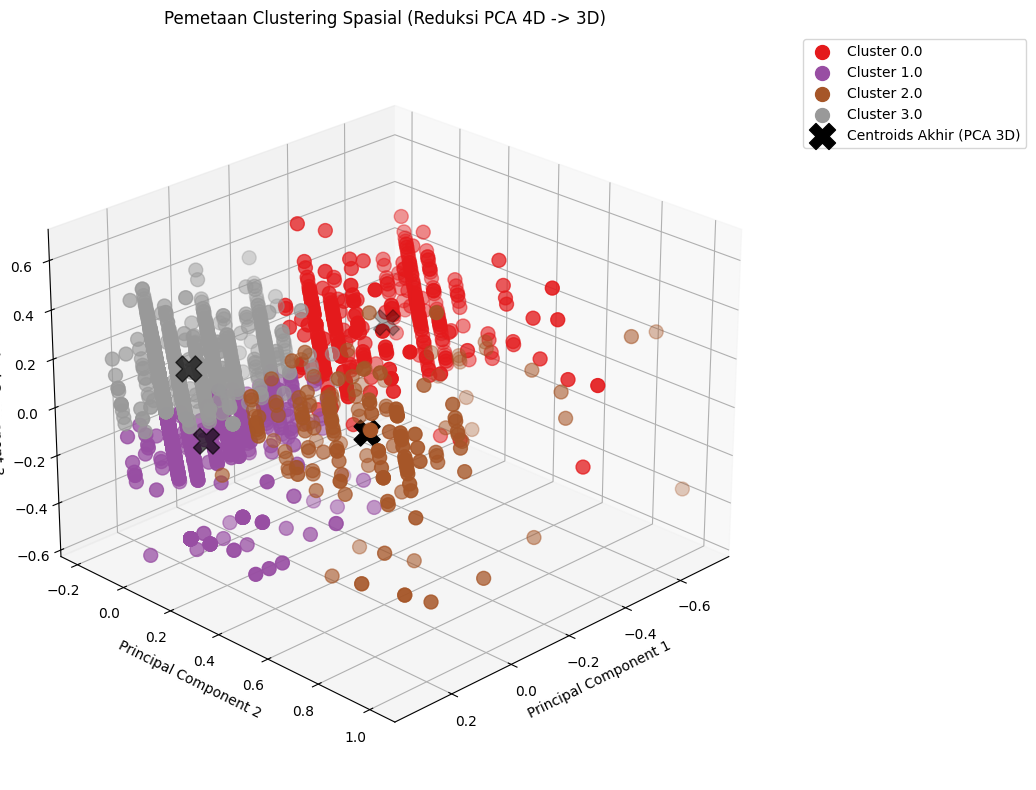

In [6]:
# Grafik secara pintar akan melihat jumlah dimensi dan melukis plot Sumbu X Y Z yang bisa di rotasi!
plot_hasil_cluster(X_scaled, kmeans_centroids_scaled, final_labels, fitur_yang_dipakai)

## 5. Metrik Evaluasi Kualitas Klasterisasi
Fungsi ini dipanggil langsung dari library buatan  untuk menguji objektivitas model (Silhouette, DBI, MAE, SSE, Calinski Harabasz).

In [7]:
# Cukup Panggil 1 baris kode saja!
evaluasi_kualitas_klasterisasi(X_scaled, final_labels, kmeans_centroids_scaled)

      HASIL UJI METRIK KUALITAS KLASTERISASI
1. Silhouette Score          : 0.3660
   [Interpretasi]: LEMAH. Klaster saling berdekatan / sedikit tumpang tindih.

2. Davies-Bouldin Index (DBI): 0.9014
   [Interpretasi]: SANGAT BAGUS. Klaster terpisah jauh dengan kepadatan terpusat.

3. Calinski-Harabasz Index   : 1913.5375
   [Interpretasi]: Semakin tinggi angka ini, semakin rapat/padat (dense) klaster Anda.

4. SSE (Sum Squared Error)   : 111.5743
   [Interpretasi]: Mengukur kuadrat jarak deviasi. Turunnya SSE di tiap iterasi membuktikan kinerja baik.

5. MAE (Mean Absolute Error) : 0.2736
   [Interpretasi]: Rata-rata 'jarak lurus' data meleset dari pusat klaster mereka.


In [14]:
import sys
import pandas as pd
sys.path.append("src")
from preprocessing import clean_and_preprocess_data
from csa_core import hitung_optimal_k_elbow, cuckoo_search_kmeans, final_kmeans, plot_hasil_cluster, evaluasi_kualitas_klasterisasi
import numpy as np

# 1. Preprocessing Data
df_raw, df_scaled, list_fitur = clean_and_preprocess_data("data/Data Set UMKM.xlsx")

X_scaled = df_scaled.values


-> Memuat dataset...


FileNotFoundError: [Errno 2] No such file or directory: 'data/Data Set UMKM.xlsx'

In [ ]:
# 2. Mencari K-Optimal secara Otomatis
print("Mencari jumlah klaster (K) optimal...")
optimal_k = hitung_optimal_k_elbow(X_scaled, max_k=8)


In [ ]:
# 3. Proses Training (Fitting) dengan Cuckoo Search Algorithm
print(f"\nMemulai Cuckoo Search dengan K={optimal_k}...")
best_nest, fitness_history = cuckoo_search_kmeans(
    X=X_scaled, 
    k=optimal_k, 
    n_nests=10, 
    max_iter=30, 
    pa=0.25
)

# 4. Fine-Tuning dengan K-Means konvensional
print("\nMelakukan Fine-Tuning K-Means...")
labels, final_centroids = final_kmeans(X_scaled, best_nest)


In [ ]:
# 5. Evaluasi Metrik & Visualisasi
evaluasi_kualitas_klasterisasi(X_scaled, labels, final_centroids)

# Memasukkan hasil klaster ke dataframe asli untuk dianalisis
df_raw["Cluster"] = labels
print("\nDistribusi Klaster:")
print(df_raw["Cluster"].value_counts())

plot_hasil_cluster(X_scaled, final_centroids, labels, list_fitur)
